In [7]:

# КОНТРОЛЬНАЯ РАБОТА: РЕГРЕССИОННЫЙ АНАЛИЗ
# ВАРИАНТ 7: Целевой признак - Age, Семейное положение - Married = False
# Маскалева Полина ЗФИбд-01-24 лабораторная 1

In [8]:
import pandas as pd
import numpy as np

# Загрузка данных из CSV файла
df = pd.read_csv('Credit_Data.csv')

# Преобразование столбца Married в формат True/False
df['Married'] = df['Married'].map({'Yes': True, 'No': False})

# Фильтрация: оставляем только записи с Married = False (вариант 7)
df_filtered = df[df['Married'] == False].copy()

# Определяем целевой признак (Age)
target = 'Age'

# Преобразуем остальные категориальные признаки в булевы значения (True/False)
df_filtered['Gender'] = df_filtered['Gender'].map({'Male': True, 'Female': False})
df_filtered['Student'] = df_filtered['Student'].map({'Yes': True, 'No': False})

In [9]:
# Парная линейная регрессия

SyntaxError: invalid syntax (2607926851.py, line 1)

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

# Список признаков, которые не используем - искоючаем
exclude_cols = ['Gender', 'Student', 'Married', 'Ethnicity', 'ID', target]

# Формируем список доступных признаков для анализа
feature_cols = [col for col in df_filtered.columns if col not in exclude_cols]

print(f"Доступные признаки для анализа: {feature_cols}")

# Вычисляем корреляцию целевого признака со всеми доступными признаками
# Для корректного расчета корреляции с булевыми значениями, преобразуем их в числа
df_corr = df_filtered.copy()
for col in df_corr.select_dtypes(include=['bool']).columns:
    df_corr[col] = df_corr[col].astype(int)

correlations = df_corr[feature_cols + [target]].corr()[target].drop(target).abs()

# Находим признак с наибольшей корреляцией
best_feature = correlations.idxmax()
best_corr = correlations[best_feature]

print(f"Признак с наибольшей корреляцией с {target}: {best_feature}")
print(f"Значение корреляции: {best_corr:.4f}")
print("Все корреляции (по убыванию):")
print(correlations.sort_values(ascending=False))

# Извлекаем данные для регрессии
X = df_filtered[best_feature].values  # Признак-предиктор
y = df_filtered[target].values        # Целевой признак

# Точные формулы для парной линейной регрессии
# a = σ_xy / σ_x^2  (коэффициент наклона)
# b = μ_y - a * μ_x (свободный член)

n = len(X)                    # Количество наблюдений
x_mean = np.mean(X)          # Среднее значение признака X
y_mean = np.mean(y)          # Среднее значение целевого признака Y

# Вычисляем ковариацию между X и Y: 
cov_xy = np.sum((X - x_mean) * (y - y_mean)) / n

# Вычисляем дисперсию X: 
var_x = np.sum((X - x_mean)**2) / n

# Вычисляем коэффициенты регрессии по формулам
a = cov_xy / var_x  # Наклон 
b = y_mean - a * x_mean  # Свободный член 

# Получаем предсказанные значения
y_pred = a * X + b

# Вычисляем коэффициент детерминации R²
r2_simple = r2_score(y, y_pred)

print(f"Коэффициенты парной лин регрессии:")
print(f"  y = {b:.4f} + {a:.4f} * x")
print(f"  R² = {r2_simple:.4f}")


БЛОК 2: ПАРНАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ
Доступные признаки для анализа: ['Income', 'Limit', 'Rating', 'Cards', 'Education', 'Balance']

Признак с наибольшей корреляцией с Age: Income
Значение корреляции: 0.1706

Все корреляции (по убыванию):
Income       0.170595
Rating       0.098352
Limit        0.094776
Cards        0.087983
Education    0.071951
Balance      0.006103
Name: Age, dtype: float64

КОЭФФИЦИЕНТЫ ПАРНОЙ ЛИНЕЙНОЙ РЕГРЕССИИ:
  y = 53.2895 + 0.0908 * x
  R² = 0.0291


In [11]:
# БЛОК 3: ВИЗУАЛИЗАЦИЯ ДИАГРАММЫ РАССЕЯНИЯ И ЛИНИИ РЕГРЕССИИ
# Точки с разными цветами (Gender) и маркерами (Student)


БЛОК 3: ВИЗУАЛИЗАЦИЯ ДИАГРАММЫ РАССЕЯНИЯ


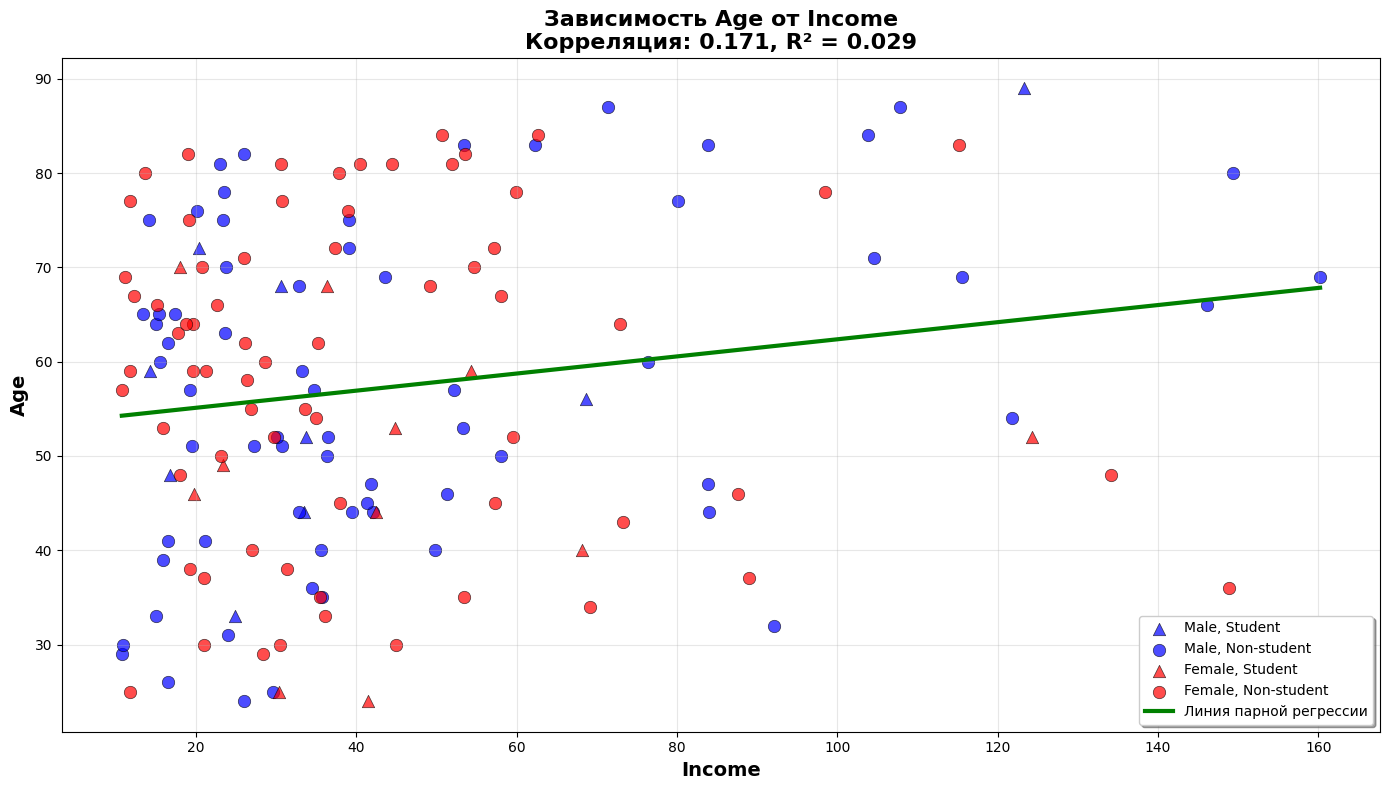

График парной регрессии построен и отображен.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем фигуру для графика
plt.figure(figsize=(14, 8))

# Gender = True (Male)   - синий цвет
# Gender = False (Female) - красный цвет
gender_colors = {True: 'blue', False: 'red'}
gender_labels = {True: 'Male', False: 'Female'}

# Student = True (Yes) - треугольник (^)
# Student = False (No)  - круг (o)
student_markers = {True: '^', False: 'o'}
student_labels = {True: 'Student', False: 'Non-student'}


for gender in [True, False]:      # Перебор значений Gender (True/False)
    for student in [True, False]:  # Перебор значений Student (True/False)
        # Создаем маску для текущей комбинации
        mask = (df_filtered['Gender'] == gender) & (df_filtered['Student'] == student)
        
        # Если есть точки с такой комбинацией, отображаем их
        if mask.any():
            plt.scatter(
                df_filtered.loc[mask, best_feature],  # X координаты
                df_filtered.loc[mask, target],        # Y координаты
                c=gender_colors[gender],              # Цвет по Gender
                marker=student_markers[student],      # Маркер по Student
                s=80,                                 # Размер точек
                alpha=0.7,                           # Прозрачность
                label=f'{gender_labels[gender]}, {student_labels[student]}',
                edgecolors='black',                  # Обводка точек
                linewidth=0.5
            )

# Линния регрессии
x_line = np.linspace(X.min(), X.max(), 100)  # 100 точек для плавной линии
y_line = b + a * x_line                      # Вычисляем y по уравнению
plt.plot(x_line, y_line, 'g-', linewidth=3, label='Линия парной регрессии')

# Создаем график
plt.xlabel(best_feature, fontsize=14, fontweight='bold')
plt.ylabel(target, fontsize=14, fontweight='bold')
plt.title(f'Зависимость {target} от {best_feature}\n'
          f'Корреляция: {best_corr:.3f}, R² = {r2_simple:.3f}', 
          fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# Множественная регрессия

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from itertools import combinations
import pandas as pd
import numpy as np

# Преобразуем булевы признаки в числа для sklearn
X_all = df_filtered[feature_cols].copy()
for col in X_all.select_dtypes(include=['bool']).columns:
    X_all[col] = X_all[col].astype(int)
    
y_all = df_filtered[target].copy()  # Целевой признак

# РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ:
# ===========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape} ({len(X_train)} записей)")
print(f"Тестовая выборка: {X_test.shape} ({len(X_test)} записей)")
print(f"Количество признаков для анализа: {len(feature_cols)}")
print(f"Количество возможных пар: {len(list(combinations(feature_cols, 2)))}")

# перебираем все возможные пары признаков
best_r2 = -np.inf  # Инициализируем лучший R^2 минимальным значением
best_pair = None   # Для хранения лучшей пары признаков
best_model = None  # Для хранения лучшей модели

# Цикл по всем комбинациям из 2 признаков
for feat1, feat2 in combinations(feature_cols, 2):
    # Выбираем только текущую пару признаков
    X_train_pair = X_train[[feat1, feat2]]
    X_test_pair = X_test[[feat1, feat2]]
    
    # Модель создаем
    model = LinearRegression()
    model.fit(X_train_pair, y_train)  # Обучение на обучающей выборке
    
    # Предсказание и оценка
    y_pred_pair = model.predict(X_test_pair)  # Предсказание на тестовой выборке
    r2 = r2_score(y_test, y_pred_pair)       # Вычисление R^2
    
    # Сохраняем лучшую модель
    if r2 > best_r2:
        best_r2 = r2
        best_pair = (feat1, feat2)
        best_model = model

print(f"Лучшая пара признаков:")
print(f"  {best_pair[0]} и {best_pair[1]}")
print(f"  R² = {best_r2:.4f}")
print(f"Коэффициенты модели множественной регрессии:")
print(f"  {best_pair[0]}: {best_model.coef_[0]:.4f}")
print(f"  {best_pair[1]}: {best_model.coef_[1]:.4f}")
print(f"  Свободный член: {best_model.intercept_:.4f}") #веззде округляем до 4 знаков

Обучающая выборка: (124, 6) (124 записей)
Тестовая выборка: (31, 6) (31 записей)
Количество признаков для анализа: 6
Количество возможных пар: 15
Лучшая пара признаков:
  Rating и Balance
  R² = 0.0685
Коэффициенты модели множественной регрессии:
  Rating: 0.0275
  Balance: -0.0066
  Свободный член: 51.0419


In [25]:
# Визуализация

/Users/polinamaskaleva/Folder/MLinFinanse_lab1/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


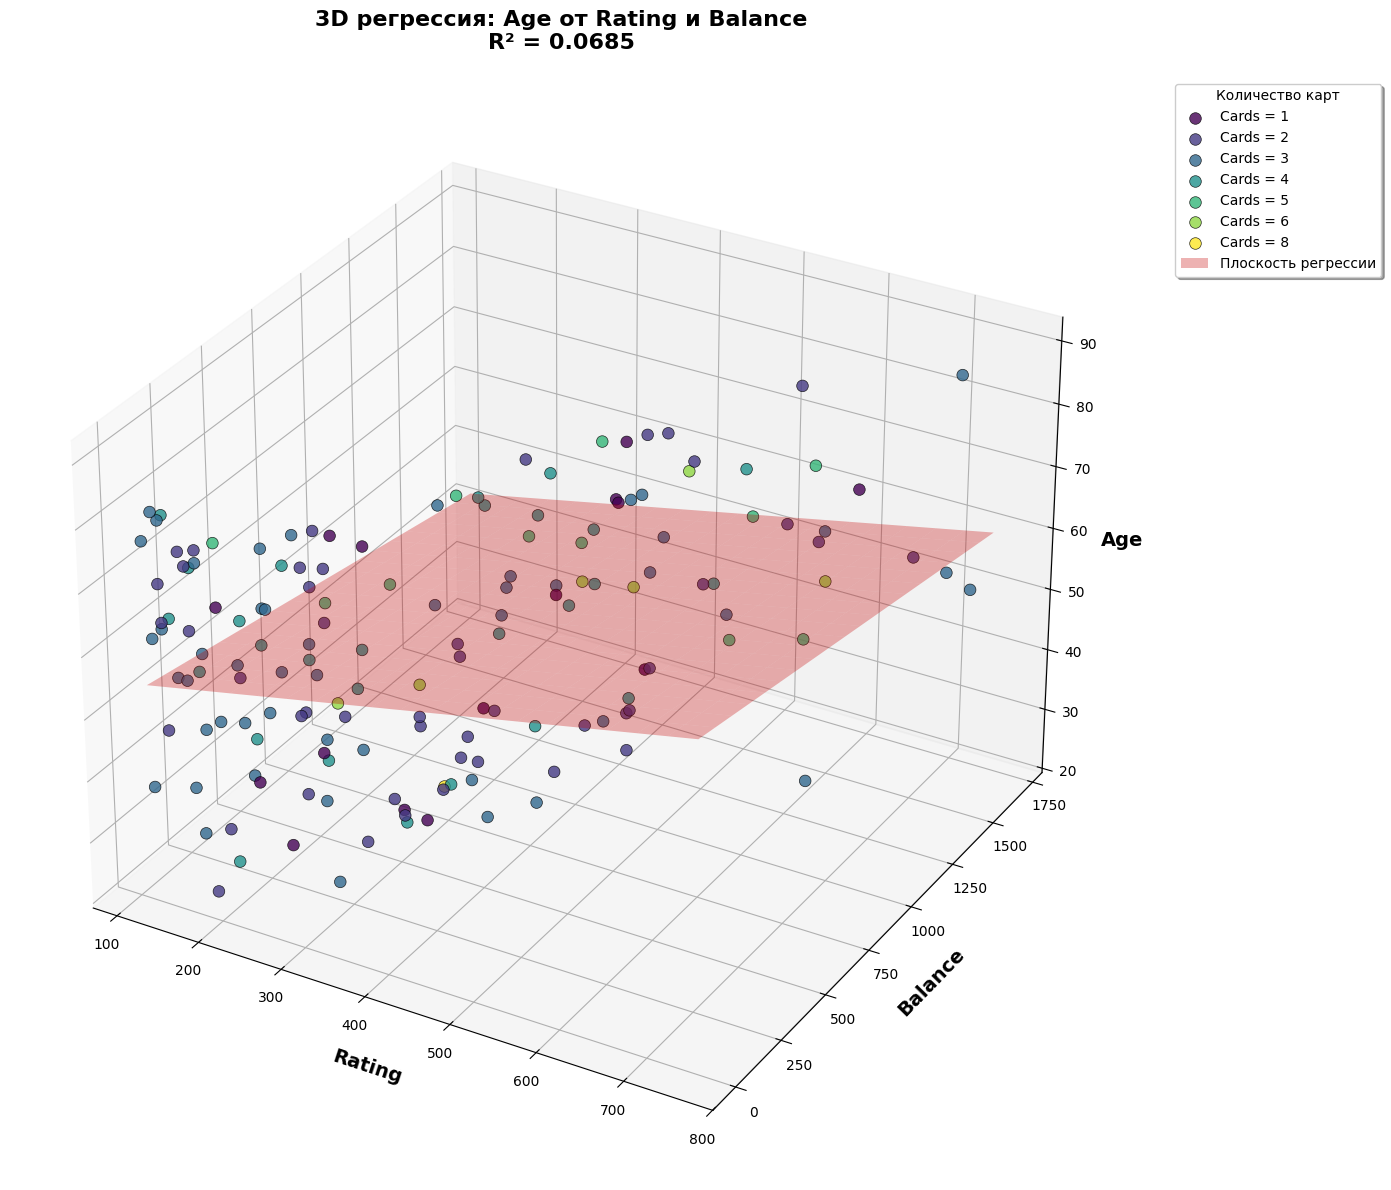

In [26]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# Создаем 3д модель:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Извлекаем данные для лучших признаков:
X1 = df_filtered[best_pair[0]].values  # Первый признак из лучшей пары
X2 = df_filtered[best_pair[1]].values  # Второй признак из лучшей пары
Y = df_filtered[target].values         # Целевой признак

cards_values = sorted(df_filtered['Cards'].unique())  # Уникальные значения Cards
colors = plt.cm.viridis(np.linspace(0, 1, len(cards_values)))  # Цветовая карта

for i, cards in enumerate(cards_values):
    mask = df_filtered['Cards'] == cards
    if mask.any():
        ax.scatter(
            X1[mask], X2[mask], Y[mask],
            c=[colors[i]], 
            s=70, 
            alpha=0.8,
            label=f'Cards = {int(cards)}',
            edgecolors='black', 
            linewidth=0.5
        )

# Строим плоскость регрессии:
# Создаем сетку точек для плоскости
x1_range = np.linspace(X1.min(), X1.max(), 20)
x2_range = np.linspace(X2.min(), X2.max(), 20)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Предсказываем значения для каждой точки сетки
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])
y_grid = best_model.predict(X_grid).reshape(x1_grid.shape)

# Отрисовываем плоскость регрессии
ax.plot_surface(
    x1_grid, x2_grid, y_grid, 
    alpha=0.3, 
    color='red',
    label='Плоскость регрессии'
)

# 3Д график:
ax.set_xlabel(best_pair[0], fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel(best_pair[1], fontsize=14, fontweight='bold', labelpad=10)
ax.set_zlabel(target, fontsize=14, fontweight='bold', labelpad=10)
ax.set_title(f'3D регрессия: {target} от {best_pair[0]} и {best_pair[1]}\n'
             f'R² = {best_r2:.4f}', 
             fontsize=16, fontweight='bold', pad=20)

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), #прописываем легенду
          fontsize=10, frameon=True, shadow=True, 
          title='Количество карт')

plt.tight_layout()
plt.show()


In [27]:
# модель Tensorflow со всеми признаками

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# Готовим данные
# Преобразуем булевы признаки в числа для TensorFlow
X_tf = df_filtered[feature_cols].copy()
for col in X_tf.select_dtypes(include=['bool']).columns:
    X_tf[col] = X_tf[col].astype(int)
    
X_tf = X_tf.values.astype(np.float32)
y_tf = df_filtered[target].values.astype(np.float32).reshape(-1, 1)

# Разделение на обучающую и тестовую выборки
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tf, y_tf, test_size=0.2, random_state=42
)

print(f"Форма данных для TensorFlow:")
print(f"  X_train: {X_train_tf.shape}")
print(f"  X_test: {X_test_tf.shape}")
print(f"  y_train: {y_train_tf.shape}")
print(f"  y_test: {y_test_tf.shape}")

# Создаем модель:
# 1. Слой нормализации 
normalizer = Normalization(axis=-1)
normalizer.adapt(X_train_tf)  # Вычисляет среднее и дисперсию на обучающих данных

# 2. Последовательная модель
tf_model = Sequential([
    normalizer,      # Слой нормализации
    Dense(1)         # Выходной слой с 1 нейроном (линейная регрессия)
])

# Компиляция:
tf_model.compile(
    optimizer='adam',           # Оптимизатор Adam
    loss='mse',                # Функция потерь - средняя квадратичная ошибка
    metrics=['mae']           # Метрика - средняя абсолютная ошибка
)

print("Структура модели:")
tf_model.summary()

# Обучение:
print("Обучение модели")
history = tf_model.fit(
    X_train_tf, y_train_tf,
    epochs=100,               # Количество эпох обучения
    verbose=0,               # Без вывода прогресса
    validation_split=0.2     # 20% обучающих данных для валидации
)
print("Обучение все.")

# Оценка:
y_pred_tf = tf_model.predict(X_test_tf, verbose=0)  # Предсказание
r2_tf = r2_score(y_test_tf, y_pred_tf)              # Вычисление R^2

print(f"Результаты модели:")
print(f"R^2 = {r2_tf:.4f}")

Форма данных для TensorFlow:
  X_train: (124, 6)
  X_test: (31, 6)
  y_train: (124, 1)
  y_test: (31, 1)
Структура модели:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (124, 6)               │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (56.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 13 (56.00 B)

Обучение модели
Обучение все.
Результаты модели:
R^2 = -9.5267


In [29]:
# Сравнение моделей

In [30]:

print("Табица моделей:")
print(f"{'Модель':<40} {'R²':<10} {'Признаки':<20}")
print(f"{'Парная регрессия':<40} {r2_simple:<10.4f} {best_feature:<20}")
print(f"{'Множественная регрессия - лучшая пара':<40} {best_r2:<10.4f} {best_pair[0]}, {best_pair[1]}")
print(f"{'Tensorflow со всеми признаками':<40} {r2_tf:<10.4f} {len(feature_cols)} признаков")

# Нахождение лучшей
if r2_tf > best_r2:
    best_overall = "Tensorlow со всеми признаками"
    improvement = ((r2_tf - best_r2) / best_r2) * 100
    print(f"Лучшая модель: {best_overall}")
    print(f"Улучшение относительно модели с парой признаков: {improvement:.2f}%")
else:
    best_overall = f"Множественная регрессия с признаками {best_pair[0]} и {best_pair[1]}"
    improvement = ((best_r2 - r2_tf) / r2_tf) * 100
    print(f"Лучшая модель: {best_overall}")
    print(f"Улучшение относительно модели TensorFlow: {improvement:.2f}%")


Табица моделей:
Модель                                   R²         Признаки            
Парная регрессия                         0.0291     Income              
Множественная регрессия - лучшая пара    0.0685     Rating, Balance
Tensorflow со всеми признаками           -9.5267    6 признаков
Лучшая модель: Множественная регрессия с признаками Rating и Balance
Улучшение относительно модели TensorFlow: -100.72%
